In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [9]:
df = pd.read_csv('netflix_titles.csv')

In [10]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:

movie_count = df[df['type'] == 'Movie'].shape[0]
tv_show_count = df[df['type'] == 'TV Show'].shape[0]

print(f"Movie sayısı: {movie_count}")
print(f"TV Show sayısı: {tv_show_count}")


Movie sayısı: 6131
TV Show sayısı: 2676


In [8]:

df['director'] = df['director'].dropna()

directors = df['director'].str.split(',').explode().str.strip()

director_counts = directors.value_counts()

most_frequent_director = director_counts.idxmax()
most_frequent_count = director_counts.max()

most_frequent_director_shows = df[df['director'].str.contains(most_frequent_director, na=False)]

print(f"En fazla yapım çeken yapımcı: {most_frequent_director}, Çektiği yapım sayısı: {most_frequent_count}")

print("\nÇektiği yapımlar:")
print(most_frequent_director_shows[['title', 'type', 'release_year']])


En fazla yapım çeken yapımcı: Rajiv Chilaka, Çektiği yapım sayısı: 22

Çektiği yapımlar:
                                                  title   type  release_year
406                        Chhota Bheem - Neeli Pahaadi  Movie          2013
407                               Chhota Bheem & Ganesh  Movie          2009
408                  Chhota Bheem & Krishna: Mayanagari  Movie          2011
409   Chhota Bheem & Krishna: Pataliputra- City of t...  Movie          2010
410                  Chhota Bheem And The Broken Amulet  Movie          2013
411              Chhota Bheem And The Crown of Valhalla  Movie          2013
412                Chhota Bheem and the Incan Adventure  Movie          2013
413                 Chhota Bheem and The ShiNobi Secret  Movie          2013
414                            Chhota Bheem Aur Hanuman  Movie          2012
415                            Chhota Bheem aur Krishna  Movie          2009
416                 Chhota Bheem aur Krishna vs Zimbara  Movie  

In [9]:

df['country'] = df['country'].dropna()

country_counts = df['country'].value_counts()

most_frequent_country = country_counts.idxmax()
most_frequent_count = country_counts.max()

most_frequent_country_shows = df[df['country'].str.contains(most_frequent_country, na=False)]

print(f"En fazla yapım çekilen ülke: {most_frequent_country}, Çekilen yapım sayısı: {most_frequent_count}")

print("\nBu ülkede çekilen yapımlar:")
print(most_frequent_country_shows[['title', 'type', 'release_year']])


En fazla yapım çekilen ülke: United States, Çekilen yapım sayısı: 2818

Bu ülkede çekilen yapımlar:
                     title     type  release_year
0     Dick Johnson Is Dead    Movie          2020
7                  Sankofa    Movie          1993
9             The Starling    Movie          2021
15       Dear White People  TV Show          2021
27               Grown Ups    Movie          2010
...                    ...      ...           ...
8793  Yours, Mine and Ours    Movie          2005
8797             Zak Storm  TV Show          2016
8802                Zodiac    Movie          2007
8804            Zombieland    Movie          2009
8805                  Zoom    Movie          2006

[3690 rows x 3 columns]


In [11]:

df['cast'] = df['cast'].dropna()

cast = df['cast'].str.split(',').explode().str.strip()

cast_counts =cast.value_counts()

most_frequent_cast = cast_counts.idxmax()
most_frequent_count = cast_counts.max()

most_frequent_cast_shows = df[df['cast'].str.contains(most_frequent_cast, na=False)]

print(f"En fazla yer alan oyuncu: {most_frequent_cast}, Oynadığı fim veya dizi sayısı: {most_frequent_count}")

print("\nÇektiği yapımlar:")
print(most_frequent_cast_shows[['title', 'type', 'release_year']])


En fazla yer alan oyuncu: Anupam Kher, Oynadığı fim veya dizi sayısı: 43

Çektiği yapımlar:
                                         title     type  release_year
192                                 C Kkompany    Movie          2008
202                          Kyaa Kool Hai Hum    Movie          2005
204                   Kyaa Super Kool Hain Hum    Movie          2012
205          Kyo Kii... Main Jhuth Nahin Bolta    Movie          2001
702                    Silver Linings Playbook    Movie          2012
1861                                       Dil    Movie          1990
2270                           Chashme Baddoor    Movie          2013
2289                                Special 26    Movie          2013
2339                      Prem Ratan Dhan Payo    Movie          2015
2340                                     Vivah    Movie          2006
2564                One Day: Justice Delivered    Movie          2019
2724                      Gori Tere Pyaar Mein    Movie          201

In [12]:

df['listed_in'] = df['listed_in'].dropna()

types = df['listed_in'].str.split(',').explode().str.strip()

type_counts = types.value_counts()

most_frequent_type = type_counts.idxmax()
most_frequent_count = type_counts.max()

most_frequent_type_shows = df[df['listed_in'].str.contains(most_frequent_type, na=False)]

print(f"En fazla çekilen tür: {most_frequent_type}, Çekilen yapım sayısı: {most_frequent_count}")

print("\nBu türdeki yapımlar:")
print(most_frequent_type_shows[['title', 'type', 'release_year']])


En fazla çekilen tür: International Movies, Çekilen yapım sayısı: 2752

Bu türdeki yapımlar:
                                                  title   type  release_year
7                                               Sankofa  Movie          1993
12                                         Je Suis Karl  Movie          2021
16    Europe's Most Dangerous Man: Otto Skorzeny in ...  Movie          2020
22                                      Avvai Shanmughi  Movie          1996
24                                                Jeans  Movie          1998
...                                                 ...    ...           ...
8794                                             اشتباك  Movie          2016
8798                                           Zed Plus  Movie          2014
8799                                              Zenda  Movie          2009
8801                                            Zinzana  Movie          2015
8806                                             Zubaan  Mov

In [20]:
import pandas as pd

df['duration'] = df['duration'].dropna()

def convert_duration(duration):
    if isinstance(duration, str):
        if 'min' in duration:  
            return int(duration.split(' ')[0]) 
        elif 'season' in duration: 
            return int(duration.split(' ')[0]) * 10 
    return None

df['duration_numeric'] = df['duration'].apply(convert_duration)

longest_duration_row = df.loc[df['duration_numeric'].idxmax()]

longest_duration_title = longest_duration_row['title']
longest_duration_value = longest_duration_row['duration_numeric']
longest_duration_type = longest_duration_row['type']

print(f"En uzun süreli film-dizi: {longest_duration_title}")
print(f"Türü: {longest_duration_type}")
print(f"Süresi: {longest_duration_value} dakika")


En uzun süreli film-dizi: Black Mirror: Bandersnatch
Türü: Movie
Süresi: 312.0 dakika


In [19]:
def convert_duration(duration):
  
    if isinstance(duration, str) and 'min' in duration:
        return int(duration.split(' ')[0]) 
    elif isinstance(duration, str) and 'season' in duration:  
        return int(duration.split(' ')[0]) * 10  
    else:
        return None 

df['duration_numeric'] = df['duration'].apply(convert_duration)

shortest_duration_row = df.loc[df['duration_numeric'].idxmin()]

print(f"En az süreye sahip film/dizi: {shortest_duration_row['title']}")
print(f"Süre: {shortest_duration_row['duration_numeric']} dakika")


En az süreye sahip film/dizi: Silent
Süre: 3.0 dakika


In [15]:

df['country'] = df['country'].dropna()

turkey_shows = df[df['country'].str.contains('Turkey', na=False)]

total_turkey_shows = turkey_shows.shape[0]

print(f"Türkiye'de çekilen film/dizi sayısı: {total_turkey_shows}")


Türkiye'de çekilen film/dizi sayısı: 113


In [16]:

df['country'] = df['country'].dropna()

turkey_shows = df[df['country'].str.contains('Turkey', na=False)]

print("Türkiye'de çekilen film ve diziler:")
print(turkey_shows[['title', 'type', 'release_year']])


Türkiye'de çekilen film ve diziler:
                                             title     type  release_year
21                          Resurrection: Ertugrul  TV Show          2018
703                                       The Gift  TV Show          2021
906   Have You Ever Seen Fireflies? - Theatre Play    Movie          1999
972                                          Fatma  TV Show          2021
976                                   Among Family    Movie          2017
...                                            ...      ...           ...
7980                                   Sen Kimsin?    Movie          2012
8682                               Vizontele Tuuba    Movie          2004
8720                     What Happens to My Family  TV Show          2016
8749                                    Winter Sun  TV Show          2014
8796                                    Yunus Emre  TV Show          2016

[113 rows x 3 columns]


In [21]:

df['country'] = df['country'].dropna()

turkey_shows = df[df['country'].str.contains('Turkey', na=False)]

players = turkey_shows['cast'].str.split(',').explode().str.strip()

player_counts = players.value_counts()

most_frequent_player = player_counts.idxmax()
most_frequent_count = player_counts.max()

print(f"Türkiye'de filmlerde en fazla yer alan oyuncu: {most_frequent_player}")
print(f"Bu oyuncu, {most_frequent_count} yapımda yer aldı.")


Türkiye'de filmlerde en fazla yer alan oyuncu: Demet Akbağ
Bu oyuncu, 13 yapımda yer aldı.


In [11]:
all_genres = df['listed_in'].dropna().str.split(',').explode().str.strip()

unique_genres = all_genres.unique()

print("Benzersiz türler:")
for genre in unique_genres:
    print(genre)


Benzersiz türler:
Documentaries
International TV Shows
TV Dramas
TV Mysteries
Crime TV Shows
TV Action & Adventure
Docuseries
Reality TV
Romantic TV Shows
TV Comedies
TV Horror
Children & Family Movies
Dramas
Independent Movies
International Movies
British TV Shows
Comedies
Spanish-Language TV Shows
Thrillers
Romantic Movies
Music & Musicals
Horror Movies
Sci-Fi & Fantasy
TV Thrillers
Kids' TV
Action & Adventure
TV Sci-Fi & Fantasy
Classic Movies
Anime Features
Sports Movies
Anime Series
Korean TV Shows
Science & Nature TV
Teen TV Shows
Cult Movies
TV Shows
Faith & Spirituality
LGBTQ Movies
Stand-Up Comedy
Movies
Stand-Up Comedy & Talk Shows
Classic & Cult TV


In [23]:

sci_fi_fantasy_and_adventure = df[df['listed_in'].str.contains("Sci-Fi & Fantasy", na=False) & 
                                  df['listed_in'].str.contains("Adventure", na=False)]

print(sci_fi_fantasy_and_adventure[['title', 'listed_in']])


                 title                                          listed_in
133            Chappie               Action & Adventure, Sci-Fi & Fantasy
143      Green Lantern               Action & Adventure, Sci-Fi & Fantasy
327            Beowulf               Action & Adventure, Sci-Fi & Fantasy
332      Deep Blue Sea  Action & Adventure, Horror Movies, Sci-Fi & Fa...
340          Inception    Action & Adventure, Sci-Fi & Fantasy, Thrillers
...                ...                                                ...
8580    Thor: Ragnarok     Action & Adventure, Comedies, Sci-Fi & Fantasy
8668    V for Vendetta       Action & Adventure, Dramas, Sci-Fi & Fantasy
8676    Viking Destiny               Action & Adventure, Sci-Fi & Fantasy
8687  Waarrior Savitri  Action & Adventure, International Movies, Sci-...
8742    Wild Wild West     Action & Adventure, Comedies, Sci-Fi & Fantasy

[166 rows x 2 columns]


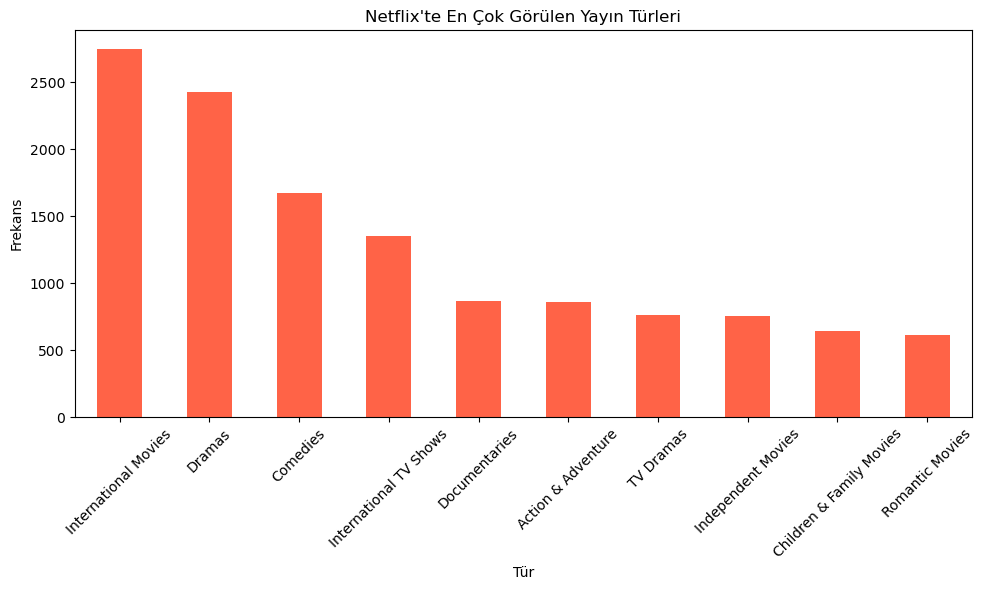

In [4]:
#Netflix'te En Çok Görülen Yayın Türleri
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")  

df = df[df["listed_in"].notnull()]

all_genres = df['listed_in'].str.split(', ').explode()

genre_counts = all_genres.value_counts().head(10)  


plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar', color='tomato')
plt.title("Netflix'te En Çok Görülen Yayın Türleri")
plt.xlabel("Tür")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


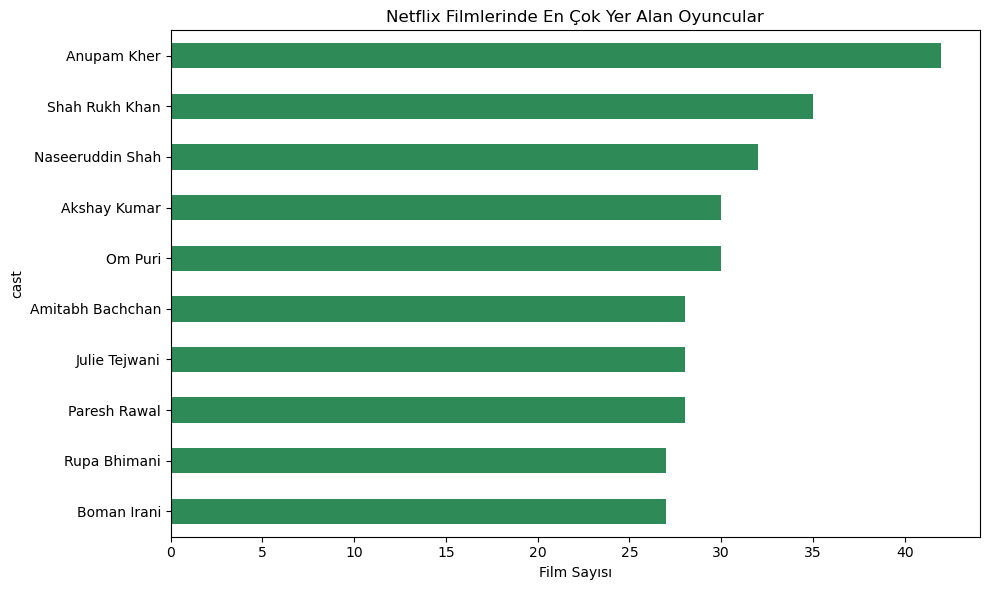

In [5]:
#Netflix Filmlerinde En Çok Yer Alan Oyuncular
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")  

df_films = df[df['type'] == 'Movie']

df_films = df_films[df_films['cast'].notnull()]

all_actors = df_films['cast'].str.split(', ').explode()

actor_counts = all_actors.value_counts().head(10)

plt.figure(figsize=(10,6))
actor_counts.plot(kind='barh', color='seagreen')
plt.title("Netflix Filmlerinde En Çok Yer Alan Oyuncular")
plt.xlabel("Film Sayısı")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


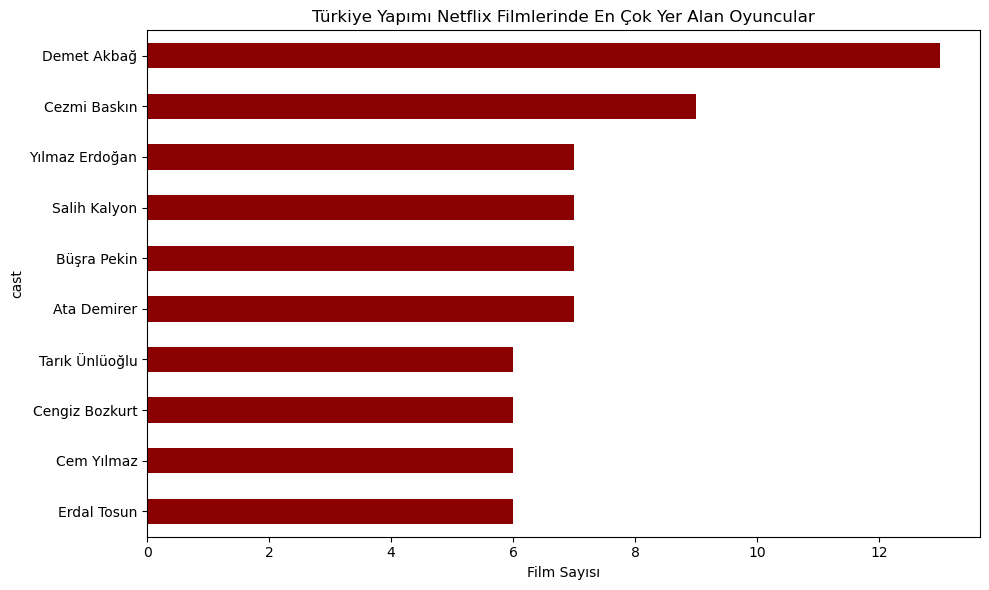

In [6]:
#Türkiye Yapımı Netflix Filmlerinde En Çok Yer Alan Oyuncular
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

df_films = df[df['type'] == 'Movie']

df_turkey = df_films[df_films['country'].str.contains('Turkey', na=False)]

df_turkey = df_turkey[df_turkey['cast'].notnull()]
all_actors = df_turkey['cast'].str.split(', ').explode()

actor_counts = all_actors.value_counts().head(10)

plt.figure(figsize=(10,6))
actor_counts.plot(kind='barh', color='darkred')
plt.title("Türkiye Yapımı Netflix Filmlerinde En Çok Yer Alan Oyuncular")
plt.xlabel("Film Sayısı")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


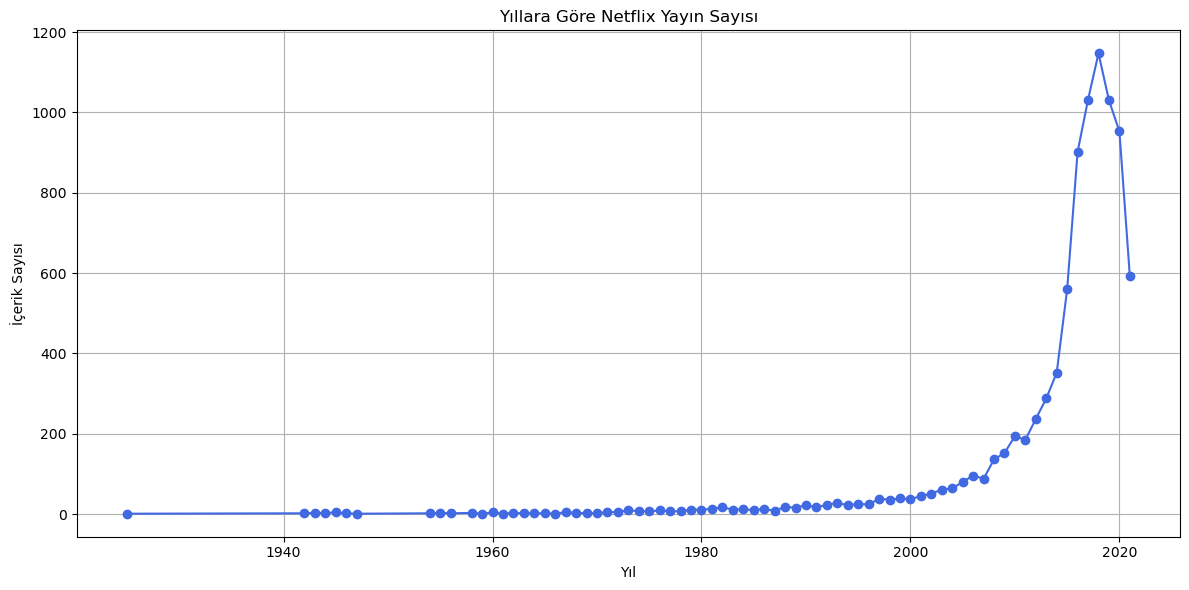

In [15]:
#Yıllara Göre Netflix Yayın Sayısı
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
year_counts.plot(kind='line', marker='o', color='royalblue')
plt.title("Yıllara Göre Netflix Yayın Sayısı")
plt.xlabel("Yıl")
plt.ylabel("İçerik Sayısı")
plt.grid(True)
plt.tight_layout()
plt.show()


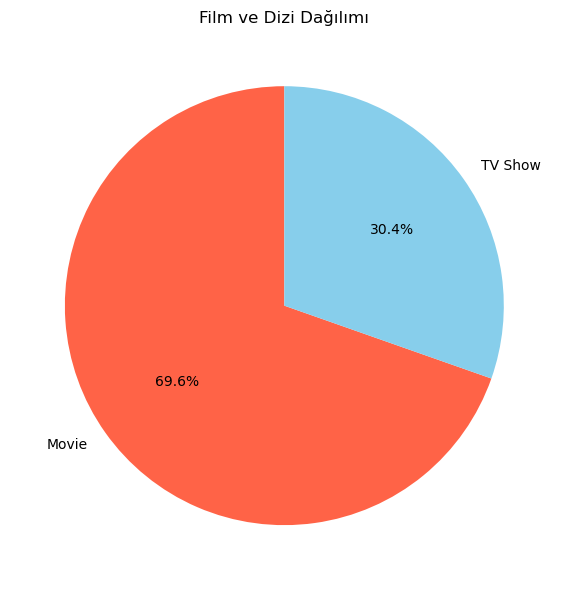

In [16]:
#Film ve Dizi Dağılımı
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,6))
type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['tomato', 'skyblue'], startangle=90)
plt.title("Film ve Dizi Dağılımı")
plt.ylabel("")
plt.tight_layout()
plt.show()


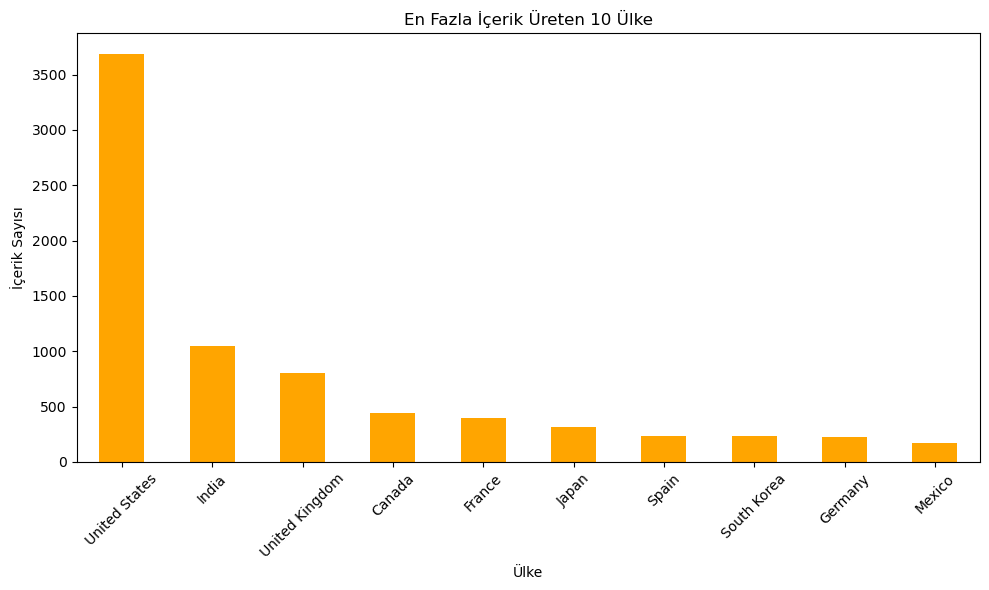

In [17]:
#En Fazla İçerik Üreten 10 Ülke
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

country_counts = df['country'].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
country_counts.plot(kind='bar', color='orange')
plt.title("En Fazla İçerik Üreten 10 Ülke")
plt.xlabel("Ülke")
plt.ylabel("İçerik Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


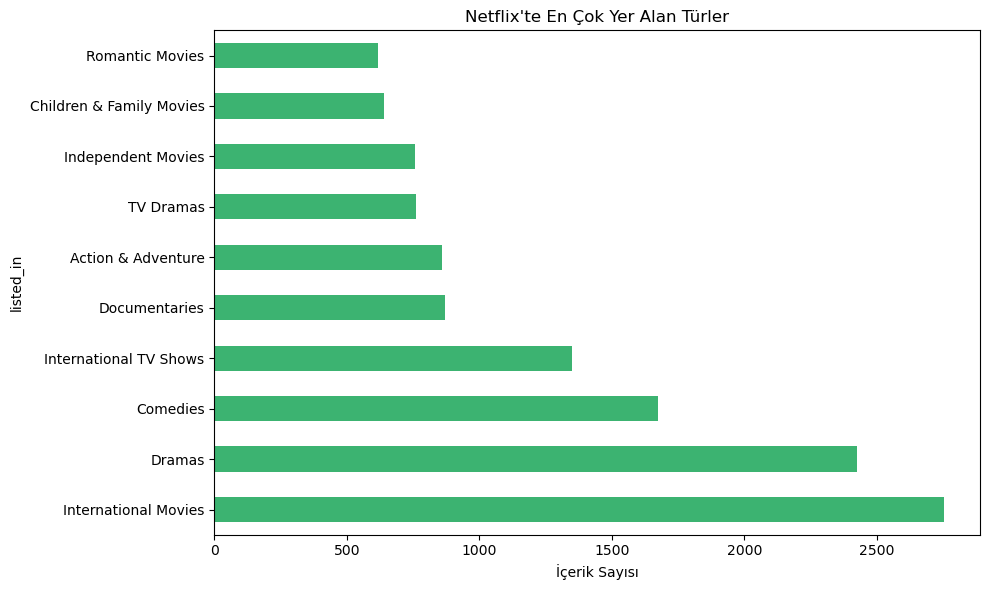

In [18]:
#Netflix'te En Çok Yer Alan Türler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

genre_counts = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
genre_counts.plot(kind='barh', color='mediumseagreen')
plt.title("Netflix'te En Çok Yer Alan Türler")
plt.xlabel("İçerik Sayısı")
plt.tight_layout()
plt.show()


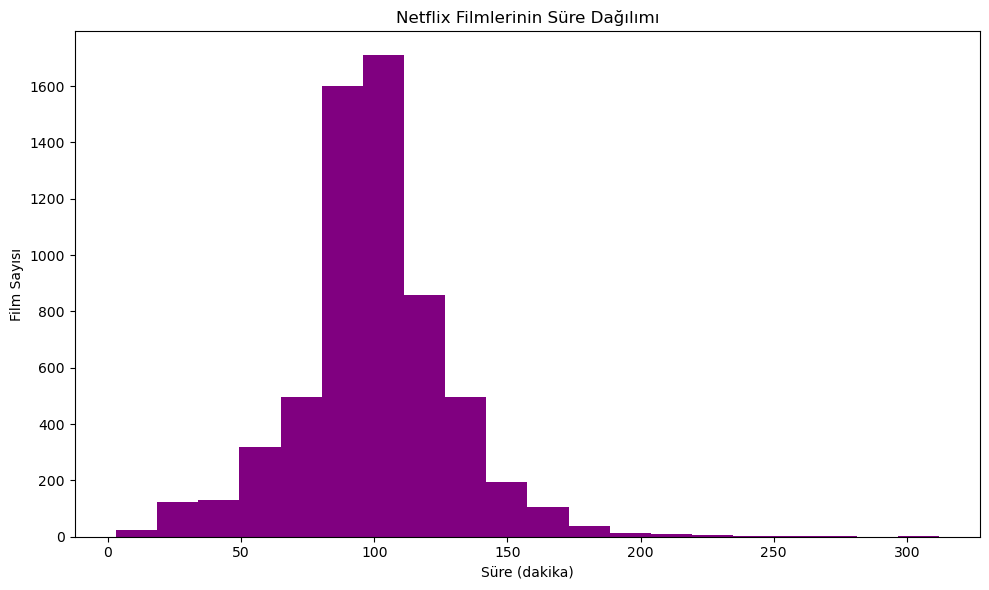

In [19]:
#Netflix Filmlerinin Süre Dağılımı
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

df_films = df[df['type'] == 'Movie'].copy()
df_films['duration_mins'] = df_films['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,6))
df_films['duration_mins'].dropna().plot(kind='hist', bins=20, color='purple')
plt.title("Netflix Filmlerinin Süre Dağılımı")
plt.xlabel("Süre (dakika)")
plt.ylabel("Film Sayısı")
plt.tight_layout()
plt.show()


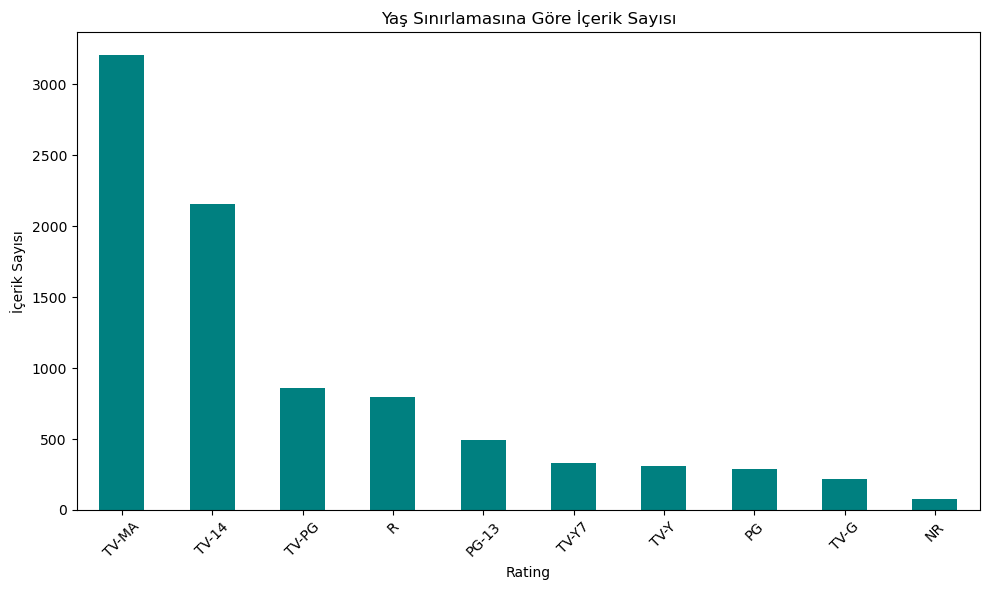

In [20]:
#Yaş Sınırlamasına Göre İçerik Sayısı
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

rating_counts = df['rating'].value_counts().head(10)
plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar', color='teal')
plt.title("Yaş Sınırlamasına Göre İçerik Sayısı")
plt.xlabel("Rating")
plt.ylabel("İçerik Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


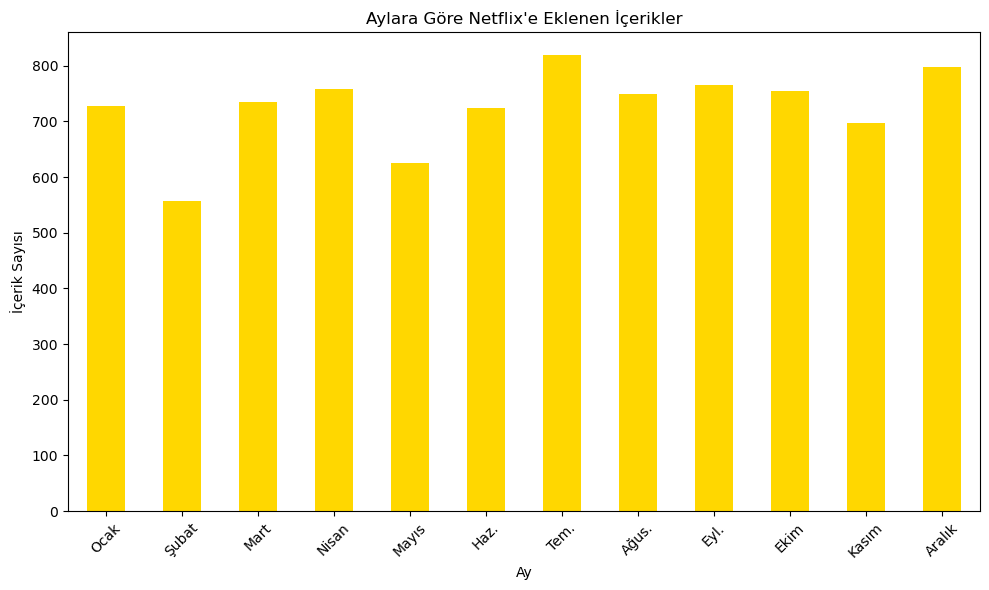

In [21]:
#Aylara Göre Netflix'e Eklenen İçerikler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month'] = df['date_added'].dt.month
month_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(10,6))
month_counts.plot(kind='bar', color='gold')
plt.title("Aylara Göre Netflix'e Eklenen İçerikler")
plt.xlabel("Ay")
plt.ylabel("İçerik Sayısı")
plt.xticks(ticks=range(0,12), labels=['Ocak', 'Şubat', 'Mart', 'Nisan', 'Mayıs', 'Haz.', 'Tem.', 'Ağus.', 'Eyl.', 'Ekim', 'Kasım', 'Aralık'], rotation=45)
plt.tight_layout()
plt.show()
